In [ ]:
!pip install tensorflow.keras

In [ ]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
df = pd.read_csv('/content/train.csv')

In [ ]:
df.isnull().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,0
pixel780,0
pixel781,0
pixel782,0


In [ ]:
y = df['label']
x = df.drop('label', axis = 1)

In [ ]:
X = x.values.reshape(-1, 28, 28, 1) / 255.0

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(X, y, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9140 - loss: 0.2963 - val_accuracy: 0.9621 - val_loss: 0.1283
Epoch 2/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9693 - loss: 0.1038 - val_accuracy: 0.9732 - val_loss: 0.0838
Epoch 3/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9803 - loss: 0.0671 - val_accuracy: 0.9786 - val_loss: 0.0669
Epoch 4/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9863 - loss: 0.0472 - val_accuracy: 0.9779 - val_loss: 0.0667
Epoch 5/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9886 - loss: 0.0372 - val_accuracy: 0.9798 - val_loss: 0.0596
Epoch 6/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9909 - loss: 0.0288 - val_accuracy: 0.9830 - val_loss: 0.0547
Epoch 7/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9935 - loss: 0.0225 - val_accuracy: 0.9812 - val_loss: 0.0657
Epoch 8/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9950 - loss: 0.0174 - val_accuracy: 0.

In [ ]:
testdf = pd.read_csv('/content/test.csv')

X_test = testdf.values.reshape(-1, 28, 28, 1) / 255.0

In [ ]:
predicted_possibilities = model.predict(X_test)
predicted_labels = tf.argmax(predicted_possibilities, axis=1)

print(f"First 5 predictions: {predicted_possibilities[:5]}")

875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
First 5 predictions: [[5.8035674e-09 2.4777327e-15 9.9999917e-01 8.1414322e-07 1.2689066e-13
  1.6577921e-11 2.0483851e-11 1.0054596e-11 6.6787920e-10 2.5794920e-12]
 [9.9999952e-01 7.5409965e-12 2.2483382e-08 1.3827641e-08 1.1064775e-13
  9.7224913e-08 2.3551003e-07 7.0419183e-08 3.3034915e-08 9.9648589e-10]
 [7.4362794e-11 4.7076154e-10 5.0498511e-06 2.2263677e-07 8.8616616e-07
  1.5238060e-06 7.6790707e-10 7.7015461e-09 9.4256056e-06 9.9998283e-01]
 [8.1420618e-01 6.6194983e-09 1.2569751e-03 1.5121255e-05 1.0819029e-03
  1.4825574e-07 3.1497795e-05 1.4684775e-03 2.8663622e-05 1.8191105e-01]
 [8.6873109e-14 4.8607706e-12 6.9776092e-08 9.9999964e-01 5.8066887e-14
  1.8342731e-09 2.7402683e-12 1.4940228e-10 2.1055293e-07 1.1315565e-11]]


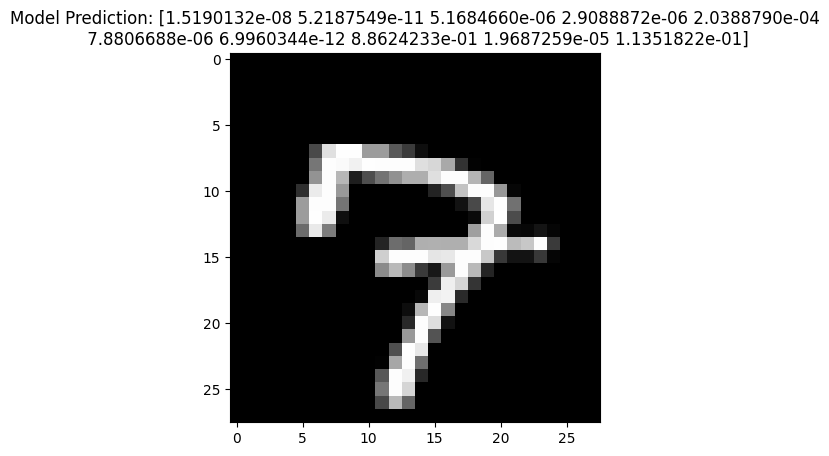

In [ ]:
import matplotlib.pyplot as plt

# Pick an image index to check
idx = 5

plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
plt.title(f"Model Prediction: {predicted_possibilities[idx]}")
plt.show()

In [ ]:
submission = pd.DataFrame({
    "ImageId": range(1, len(predicted_labels) + 1),
    "Label": predicted_labels
})

submission.to_csv('submission.csv', index=False)

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pandas as pd

X_train_flat = X.reshape(-1, 784)
X_test_flat = X_test.reshape(-1, 784)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

svm_model = SVC(kernel='rbf', C=10, gamma='scale')

svm_model.fit(X_train_scaled, y)

svm_predictions = svm_model.predict(X_test_scaled)

In [ ]:
submission_svm = pd.DataFrame({
    "ImageId": range(1, len(svm_predictions) + 1),
    "Label": svm_predictions
})

submission_svm.to_csv('submission_svm.csv', index=False)